# 📓 Step 02 — Feature Extraction

> *"We removed null features from the Edge-IIoTset dataset during our initial exploration,*
> *identifying 61 distinct and diverse features. These features are sufficiently various*
> *to distinguish the distinctive patterns of network attacks exclusively."*
> — SecurityBERT Paper, Section III-B

---

## 🎯 Objective
Extract the **61 meaningful network traffic features** from the cleaned dataset,
drop all non-informative columns (IPs, timestamps, raw payloads), and prepare
a clean feature matrix ready for PPFLE encoding in Notebook 03.

## 📋 Notebook Roadmap

| Step | Task | Output |
|------|------|--------|
| 1 | Imports & Setup | — |
| 2 | Load Cleaned Dataset | DataFrame |
| 3 | Identify all 61 features (paper taxonomy) | Feature list |
| 4 | Drop non-feature columns | Filtered DataFrame |
| 5 | Protocol-wise feature breakdown | Protocol analysis |
| 6 | Handle remaining categorical columns | Encoded DataFrame |
| 7 | Feature correlation analysis | Correlation heatmap |
| 8 | Feature importance (Random Forest) | Importance chart |
| 9 | Final feature set validation | Validation report |
| 10 | Save extracted features | `data/processed/features_extracted.csv` |

---

## 🗂️ Feature Sources (from Edge-IIoTset Paper)

Features are gathered from **4 sources** across **10 protocols**:

| Source | Description |
|--------|-------------|
| **Network traffic** | PCAP files captured via Wireshark |
| **System logs** | Edge server logs |
| **System resources** | CPU, memory usage |
| **Alerts** | Security Onion alerts |

| Protocol | Features Selected |
|----------|-------------------|
| IP | 2 |
| ARP | 4 |
| ICMP | 4 |
| HTTP | 9 |
| TCP | 15 |
| UDP | 3 |
| DNS | 7 |
| MQTT | 13 |
| Modbus/TCP | 3 |
| Frame | 1 |
| **Total** | **61** |

## 🧱 Step 1 — Imports & Setup

In [35]:
# ── Standard library ──────────────────────────────────────────────────────────
import warnings
import gc
from pathlib import Path

# ── Data ──────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── ML ────────────────────────────────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import shuffle

# ── Visualization ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')

# ── Display settings ──────────────────────────────────────────────────────────
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

# ── Plot theme ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor' : '#0f0f1a',
    'axes.facecolor'   : '#16162a',
    'axes.edgecolor'   : '#444477',
    'axes.labelcolor'  : '#ccccff',
    'xtick.color'      : '#aaaacc',
    'ytick.color'      : '#aaaacc',
    'text.color'       : '#e0e0ff',
    'grid.color'       : '#2a2a4a',
    'grid.linestyle'   : '--',
    'grid.alpha'       : 0.5,
    'font.family'      : 'DejaVu Sans',
    'axes.titlesize'   : 14,
    'axes.labelsize'   : 11,
    'legend.facecolor' : '#1a1a2e',
    'legend.edgecolor' : '#444477',
})

ACCENT  = '#7c6cfa'
GREEN   = '#4ecca3'
RED     = '#fc5c65'
YELLOW  = '#f7b731'
PALETTE = [
    '#7c6cfa', '#4ecca3', '#f7b731', '#fc5c65', '#45aaf2',
    '#fd9644', '#26de81', '#a55eea', '#2bcbba', '#eb3b5a',
    '#20bf6b', '#0fb9b1', '#8854d0', '#4b6584', '#778ca3'
]

# ── Project paths ─────────────────────────────────────────────────────────────
BASE_DIR    = Path('..')
DATA_DIR    = BASE_DIR / 'data'
PROC_DIR    = DATA_DIR / 'processed'
OUTPUT_DIR  = BASE_DIR / 'outputs' / 'figures' / 'N2'

INPUT_PATH  = PROC_DIR / 'cleaned_dataset.csv'
OUTPUT_PATH = PROC_DIR / 'features_extracted.csv'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Constants ─────────────────────────────────────────────────────────────────
TARGET_COLUMN = 'Attack_type'
CHUNK_SIZE    = 50_000
RANDOM_STATE  = 42

print('✅ Environment ready.')
print(f'   pandas  : {pd.__version__}')
print(f'   numpy   : {np.__version__}')
print(f'   Input   : {INPUT_PATH}')
print(f'   Output  : {OUTPUT_PATH}')

✅ Environment ready.
   pandas  : 3.0.2
   numpy   : 2.4.3
   Input   : ..\data\processed\cleaned_dataset.csv
   Output  : ..\data\processed\features_extracted.csv


## 📂 Step 2 — Load Cleaned Dataset

In [36]:
assert INPUT_PATH.exists(), (
    f'❌ File not found: {INPUT_PATH.resolve()}\n'
    f'   Please run Notebook 01 (Dataset Utilization) first.'
)

print(f'📁 File size : {INPUT_PATH.stat().st_size / 1e6:.1f} MB')
print('🔄 Loading in chunks …')

chunks = []
for chunk in pd.read_csv(INPUT_PATH, chunksize=CHUNK_SIZE, low_memory=False):
    chunks.append(chunk)

df = pd.concat(chunks, ignore_index=True)
del chunks
gc.collect()

print(f'✅ Loaded  {len(df):,} rows × {df.shape[1]} columns')
print(f'   RAM    : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
print(f'\n🎲 Quick peek (3 random rows):')
display(df.sample(3, random_state=RANDOM_STATE))

📁 File size : 1219.8 MB
🔄 Loading in chunks …
✅ Loaded  2,218,386 rows × 63 columns
   RAM    : 3325.5 MB

🎲 Quick peek (3 random rows):


,frame.time,ip.src_host,ip.dst_host,arp.dst.proto_ipv4,arp.opcode,arp.hw.size,arp.src.proto_ipv4,icmp.checksum,icmp.seq_le,icmp.transmit_timestamp,icmp.unused,http.file_data,http.content_length,http.request.uri.query,http.request.method,http.referer,http.request.full_uri,http.request.version,http.response,http.tls_port,tcp.ack,tcp.ack_raw,tcp.checksum,tcp.connection.fin,tcp.connection.rst,tcp.connection.syn,tcp.connection.synack,tcp.dstport,tcp.flags,tcp.flags.ack,tcp.len,tcp.options,tcp.payload,tcp.seq,tcp.srcport,udp.port,udp.stream,udp.time_delta,dns.qry.name,dns.qry.name.len,dns.qry.qu,dns.qry.type,dns.retransmission,dns.retransmit_request,dns.retransmit_request_in,mqtt.conack.flags,mqtt.conflag.cleansess,mqtt.conflags,mqtt.hdrflags,mqtt.len,mqtt.msg_decoded_as,mqtt.msg,mqtt.msgtype,mqtt.proto_len,mqtt.protoname,mqtt.topic,mqtt.topic_len,mqtt.ver,mbtcp.len,mbtcp.trans_id,mbtcp.unit_id,Attack_label,Attack_type
593348,2021 19:40:27.597521000,0,0,0,0.0000,0.0000,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,413519.0000,2372038200.0000,38287.0000,0.0000,0.0000,0.0000,0.0000,60944.0000,16.0000,1.0000,1440.0000,0,1af84dfa4081e7057644890ffd9b9013cbead0f73d39a5...,108802356.0000,5900.0000,0.0000,0.0000,0.0000,0.0000,0,0.0000,0.0000,0.0000,0.0000,0.0000,0,0.0000,0.0000,0.0000,0.0000,0.0000,0,0.0000,0.0000,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0,Normal
589711,2021 19:39:41.205592000,0,0,0,0.0000,0.0000,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,404286.0000,2372028967.0000,27133.0000,0.0000,0.0000,0.0000,0.0000,60944.0000,16.0000,1.0000,0.0000,0,0,106542303.0000,5900.0000,0.0000,0.0000,0.0000,0.0000,0,0.0000,0.0000,0.0000,0.0000,0.0000,0,0.0000,0.0000,0.0000,0.0000,0.0000,0,0.0000,0.0000,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0,Normal
994049,2021 17:42:05.921035000,192.168.0.128,192.168.0.101,0,0.0000,0.0000,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,59.0000,3138946361.0000,231.0000,0.0000,0.0000,0.0000,0.0000,51653.0000,16.0000,1.0000,0.0000,0,0,6.0000,1883.0000,0.0000,0.0000,0.0000,0.0000,0,0.0000,0.0000,0.0000,0.0000,0.0000,0,0.0000,0.0000,0.0000,0.0000,0.0000,0,0.0000,0.0000,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0,Normal


## 🗂️ Step 3 — Identify the 61 Features (Paper Taxonomy)

The SecurityBERT and Edge-IIoTset papers identify **61 features** with high
correlation selected from **1,176 total attributes** found across all protocols.

Below we define all 61 features grouped by protocol — exactly as in **Table 7**
of the Edge-IIoTset paper and **Table II** of the SecurityBERT paper.

In [37]:
# ── All 61 features grouped by protocol (Table 7 — Edge-IIoTset paper) ────────
FEATURES_BY_PROTOCOL = {
    'Frame': [
        'frame.time',                       # Arrival Time (will be dropped — timestamp)
    ],
    'IP': [
        'ip.src_host',                      # Source Host
        'ip.dst_host',                      # Destination Host
    ],
    'ARP': [
        'arp.dst.proto_ipv4',               # Target IP address
        'arp.opcode',                       # Opcode
        'arp.hw.size',                      # Hardware size
        'arp.src.proto_ipv4',               # Sender IP address
    ],
    'ICMP': [
        'icmp.checksum',                    # Checksum
        'icmp.seq_le',                      # Sequence Number
        'icmp.transmit_timestamp',          # Transmit Timestamp (will be dropped)
        'icmp.unused',                      # Unused
    ],
    'HTTP': [
        'http.file_data',                   # File Data (will be dropped — payload)
        'http.content_length',              # Content length
        'http.request.uri.query',           # Request URI Query (will be dropped)
        'http.request.method',              # Request Method
        'http.referer',                     # Referer
        'http.request.full_uri',            # Full request URI (will be dropped)
        'http.request.version',             # Request Version
        'http.response',                    # Response
        'http.tls_port',                    # TLS Port
    ],
    'TCP': [
        'tcp.ack',                          # Acknowledgment Number
        'tcp.ack_raw',                      # Acknowledgment number (raw)
        'tcp.checksum',                     # Checksum
        'tcp.connection.fin',               # Connection finish (FIN)
        'tcp.connection.rst',               # Connection reset (RST)
        'tcp.connection.syn',               # Connection SYN
        'tcp.connection.synack',            # Connection SYN+ACK
        'tcp.dstport',                      # Destination Port (will be dropped)
        'tcp.flags',                        # Flags
        'tcp.flags.ack',                    # Acknowledgment flag
        'tcp.len',                          # TCP Segment Length
        'tcp.options',                      # TCP Options (will be dropped)
        'tcp.payload',                      # TCP payload (will be dropped)
        'tcp.seq',                          # Sequence Number
        'tcp.srcport',                      # Source Port (will be dropped)
    ],
    'UDP': [
        'udp.port',                         # Source or Destination Port (will be dropped)
        'udp.stream',                       # Stream index
        'udp.time_delta',                   # Time since previous frame
    ],
    'DNS': [
        'dns.qry.name',                     # Name
        'dns.qry.name.len',                 # Name Length
        'dns.qry.qu',                       # QU question
        'dns.qry.type',                     # Type
        'dns.retransmission',               # Retransmission
        'dns.retransmit_request',           # Retransmitted request label
        'dns.retransmit_request_in',        # Original request frame number
    ],
    'MQTT': [
        'mqtt.conack.flags',                # Acknowledge Flags
        'mqtt.conflag.cleansess',           # Clean Session Flag
        'mqtt.conflags',                    # Connect Flags
        'mqtt.hdrflags',                    # Header Flags
        'mqtt.len',                         # Message Length
        'mqtt.msg_decoded_as',              # Message decoded as
        'mqtt.msg',                         # Message (will be dropped — payload)
        'mqtt.msgtype',                     # Message Type
        'mqtt.proto_len',                   # Protocol Name Length
        'mqtt.protoname',                   # Protocol Name
        'mqtt.topic',                       # Topic
        'mqtt.topic_len',                   # Topic Length
        'mqtt.ver',                         # Version
    ],
    'Modbus/TCP': [
        'mbtcp.len',                        # Length
        'mbtcp.trans_id',                   # Transaction Identifier
        'mbtcp.unit_id',                    # Unit Identifier
    ],
}

# ── Flatten to full feature list ──────────────────────────────────────────────
ALL_61_FEATURES = [f for feats in FEATURES_BY_PROTOCOL.values() for f in feats]

print(f'📋 Total features defined : {len(ALL_61_FEATURES)}')
print()
print(f'{"Protocol":<15} {"Features":>10}')
print('-' * 30)
for proto, feats in FEATURES_BY_PROTOCOL.items():
    print(f'  {proto:<13} {len(feats):>10}')
print('-' * 30)
print(f'  {"TOTAL":<13} {len(ALL_61_FEATURES):>10}')

📋 Total features defined : 61

Protocol          Features
------------------------------
  Frame                  1
  IP                     2
  ARP                    4
  ICMP                   4
  HTTP                   9
  TCP                   15
  UDP                    3
  DNS                    7
  MQTT                  13
  Modbus/TCP             3
------------------------------
  TOTAL                 61


## 🗑️ Step 4 — Drop Non-Feature Columns

Columns to remove fall into **5 categories** as identified in the SecurityBERT paper
(Section III-C) and Edge-IIoTset paper (Section VI):

| Category | Reason | Columns |
|----------|---------|---------|
| **IP addresses** | Unique identifiers → overfitting | `ip.src_host`, `ip.dst_host`, `arp.src.proto_ipv4`, `arp.dst.proto_ipv4` |
| **Timestamps** | Millisecond precision → noise | `frame.time`, `icmp.transmit_timestamp` |
| **Raw payloads** | Unstructured → noise | `tcp.payload`, `http.file_data`, `mqtt.msg` |
| **High-cardinality** | Non-generalizable patterns | `http.request.full_uri`, `http.request.uri.query` |
| **Port columns** | Redundant with flow features | `tcp.srcport`, `tcp.dstport`, `udp.port`, `tcp.options` |
| **Label columns** | Not features | `Attack_label` |

In [38]:
# ── Columns to drop (paper-specified) ────────────────────────────────────────
DROP_COLUMNS = {
    'IP addresses (overfitting risk)': [
        'ip.src_host',
        'ip.dst_host',
        'arp.src.proto_ipv4',
        'arp.dst.proto_ipv4',
    ],
    'Timestamps (noise)': [
        'frame.time',
        'icmp.transmit_timestamp',
    ],
    'Raw payloads (unstructured noise)': [
        'tcp.payload',
        'http.file_data',
        'mqtt.msg',
    ],
    'High-cardinality (non-generalizable)': [
        'http.request.full_uri',
        'http.request.uri.query',
    ],
    'Redundant port/option columns': [
        'tcp.srcport',
        'tcp.dstport',
        'udp.port',
        'tcp.options',
    ],
    'Label columns (not features)': [
        'Attack_label',
    ],
}

# ── Apply drops with detailed reporting ───────────────────────────────────────
shape_before   = df.shape
total_dropped  = 0

print(f'📐 Shape before dropping : {shape_before}')
print()

for reason, cols in DROP_COLUMNS.items():
    existing = [c for c in cols if c in df.columns]
    missing  = [c for c in cols if c not in df.columns]
    if existing:
        df.drop(columns=existing, inplace=True)
        total_dropped += len(existing)
        print(f'  🗑️  {reason}')
        for c in existing:
            print(f'       - {c}')
    if missing:
        print(f'  ⚠️  Already absent (skipped): {missing}')
    print()

print(f'📐 Shape after dropping  : {df.shape}')
print(f'   Columns removed      : {total_dropped}')
print(f'   Feature columns left : {df.shape[1] - 1}  (excl. "{TARGET_COLUMN}")')

📐 Shape before dropping : (2218386, 63)

  🗑️  IP addresses (overfitting risk)
       - ip.src_host
       - ip.dst_host
       - arp.src.proto_ipv4
       - arp.dst.proto_ipv4

  🗑️  Timestamps (noise)
       - frame.time
       - icmp.transmit_timestamp

  🗑️  Raw payloads (unstructured noise)
       - tcp.payload
       - http.file_data
       - mqtt.msg

  🗑️  High-cardinality (non-generalizable)
       - http.request.full_uri
       - http.request.uri.query

  🗑️  Redundant port/option columns
       - tcp.srcport
       - tcp.dstport
       - udp.port
       - tcp.options

  🗑️  Label columns (not features)
       - Attack_label

📐 Shape after dropping  : (2218386, 47)
   Columns removed      : 16
   Feature columns left : 46  (excl. "Attack_type")


## 📡 Step 5 — Protocol-wise Feature Breakdown

Visualize which protocols contribute how many features to the final set.

In [39]:
# ── Map remaining columns to their protocol ───────────────────────────────────
remaining_features = [c for c in df.columns if c != TARGET_COLUMN]

# Build reverse lookup: feature → protocol
feature_to_protocol = {}
for proto, feats in FEATURES_BY_PROTOCOL.items():
    for f in feats:
        feature_to_protocol[f] = proto

# Count remaining features per protocol
protocol_counts = {}
unmatched       = []
for feat in remaining_features:
    proto = feature_to_protocol.get(feat, 'Other')
    if proto == 'Other':
        unmatched.append(feat)
    protocol_counts[proto] = protocol_counts.get(proto, 0) + 1

print(f'📡 Remaining features by protocol:\n')
print(f'  {"Protocol":<20} {"Count":>8}  {"Features"}')
print('  ' + '-' * 70)
for proto, cnt in sorted(protocol_counts.items(), key=lambda x: -x[1]):
    feats_in_proto = [
        f for f in remaining_features
        if feature_to_protocol.get(f, 'Other') == proto
    ]
    print(f'  {proto:<20} {cnt:>8}  {feats_in_proto}')

if unmatched:
    print(f'\n  ⚠️  Unmatched columns (not in 61-feature list): {unmatched}')

print(f'\n  Total remaining features : {len(remaining_features)}')

📡 Remaining features by protocol:

  Protocol                Count  Features
  ----------------------------------------------------------------------
  MQTT                       12  ['mqtt.conack.flags', 'mqtt.conflag.cleansess', 'mqtt.conflags', 'mqtt.hdrflags', 'mqtt.len', 'mqtt.msg_decoded_as', 'mqtt.msgtype', 'mqtt.proto_len', 'mqtt.protoname', 'mqtt.topic', 'mqtt.topic_len', 'mqtt.ver']
  TCP                        11  ['tcp.ack', 'tcp.ack_raw', 'tcp.checksum', 'tcp.connection.fin', 'tcp.connection.rst', 'tcp.connection.syn', 'tcp.connection.synack', 'tcp.flags', 'tcp.flags.ack', 'tcp.len', 'tcp.seq']
  DNS                         7  ['dns.qry.name', 'dns.qry.name.len', 'dns.qry.qu', 'dns.qry.type', 'dns.retransmission', 'dns.retransmit_request', 'dns.retransmit_request_in']
  HTTP                        6  ['http.content_length', 'http.request.method', 'http.referer', 'http.request.version', 'http.response', 'http.tls_port']
  ICMP                        3  ['icmp.checksum', 'ic

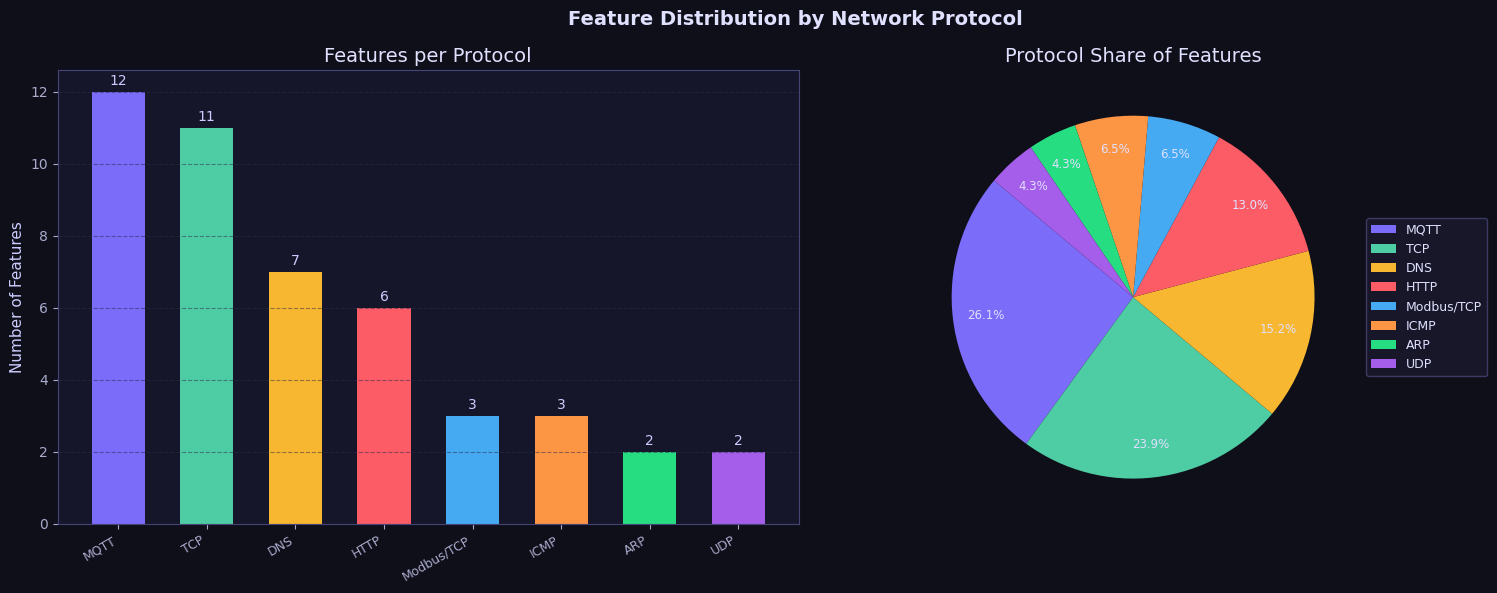

💾 Saved → ..\outputs\figures\N2/feature_protocol_breakdown.png


In [40]:
# ── Figure: Protocol contribution pie + bar ────────────────────────────────────
proto_series = pd.Series(protocol_counts).sort_values(ascending=False)
proto_colors = PALETTE[:len(proto_series)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    'Feature Distribution by Network Protocol',
    fontsize=14, fontweight='bold', color='#e0e0ff'
)

# Bar chart
ax1 = axes[0]
bars = ax1.bar(
    range(len(proto_series)), proto_series.values,
    color=proto_colors, edgecolor='none', width=0.6
)
ax1.set_xticks(range(len(proto_series)))
ax1.set_xticklabels(proto_series.index, rotation=30, ha='right', fontsize=9)
ax1.set_ylabel('Number of Features')
ax1.set_title('Features per Protocol')
ax1.bar_label(bars, fmt='%d', padding=3, fontsize=10, color='#ccccff')
ax1.grid(axis='y')

# Pie chart
ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    proto_series.values,
    labels=None,
    colors=proto_colors,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.82,
)
for at in autotexts:
    at.set_fontsize(8.5)
    at.set_color('#e0e0ff')
ax2.legend(
    wedges, proto_series.index,
    loc='center left', bbox_to_anchor=(1, 0.5), fontsize=9
)
ax2.set_title('Protocol Share of Features')

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'feature_protocol_breakdown.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f'💾 Saved → {OUTPUT_DIR}/feature_protocol_breakdown.png')

## 🔢 Step 6 — Handle Remaining Categorical Columns

String/object columns that survived the drop step must be
encoded to numeric so they can be used by ML models and PPFLE.

Strategy:
- **Low-cardinality strings** (< 50 unique) → Label Encoding
- **Boolean-like columns** → cast to int (0/1)
- **Numeric strings** → cast to float

In [41]:
# ── Identify object/string columns (excluding target) ─────────────────────────
obj_cols = [
    c for c in df.select_dtypes(include=['object', 'str']).columns
    if c != TARGET_COLUMN
]

print(f'🔡 String/object columns to encode : {len(obj_cols)}')
print()

label_encoders  = {}
encoding_report = []

for col in obj_cols:
    n_unique = df[col].nunique()
    sample   = df[col].dropna().iloc[0] if len(df[col].dropna()) > 0 else 'N/A'

    # Try numeric cast first
    try:
        df[col] = pd.to_numeric(df[col], errors='raise')
        method  = 'numeric cast'
    except (ValueError, TypeError):
        # Label encode
        le          = LabelEncoder()
        df[col]     = le.fit_transform(df[col].astype(str))
        label_encoders[col] = le
        method      = f'LabelEncoder ({n_unique} classes)'

    encoding_report.append({
        'Column'  : col,
        'Unique'  : n_unique,
        'Method'  : method,
        'Sample'  : str(sample)[:30],
    })
    print(f'  [{col:<40}]  unique={n_unique:>6}  →  {method}')

print(f'\n✅ Encoding complete.')
print(f'   Columns encoded : {len(obj_cols)}')

# Remaining dtypes summary
dtype_summary = df.drop(columns=[TARGET_COLUMN]).dtypes.value_counts()
print(f'\n📊 Feature dtype distribution after encoding:')
for dtype, cnt in dtype_summary.items():
    print(f'   {str(dtype):<15} : {cnt} columns')

🔡 String/object columns to encode : 7

  [http.request.method                     ]  unique=    10  →  LabelEncoder (10 classes)
  [http.referer                            ]  unique=     6  →  LabelEncoder (6 classes)
  [http.request.version                    ]  unique=    14  →  LabelEncoder (14 classes)
  [dns.qry.name.len                        ]  unique=    11  →  LabelEncoder (11 classes)
  [mqtt.conack.flags                       ]  unique=    14  →  LabelEncoder (14 classes)
  [mqtt.protoname                          ]  unique=     4  →  LabelEncoder (4 classes)
  [mqtt.topic                              ]  unique=     4  →  LabelEncoder (4 classes)

✅ Encoding complete.
   Columns encoded : 7

📊 Feature dtype distribution after encoding:
   float64         : 39 columns
   int64           : 7 columns


## 🔗 Step 7 — Feature Correlation Analysis

Identify highly correlated features that may introduce multicollinearity.
The paper explicitly warns about features like `ip.src_host` and
`arp.src.proto_ipv4` being redundant — we verify the remaining set is clean.

In [42]:
# ── Correlation matrix on a sample (full dataset too large for corr matrix) ───
SAMPLE_SIZE = 50_000
df_sample   = df.sample(min(SAMPLE_SIZE, len(df)), random_state=RANDOM_STATE)

feature_cols = [c for c in df_sample.columns if c != TARGET_COLUMN]
corr_matrix  = df_sample[feature_cols].astype(float).corr().abs()

# ── Find highly correlated pairs ──────────────────────────────────────────────
CORR_THRESHOLD = 0.95
upper_tri      = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
high_corr_pairs = [
    (col, row, upper_tri.loc[row, col])
    for col in upper_tri.columns
    for row in upper_tri.index
    if upper_tri.loc[row, col] >= CORR_THRESHOLD
]

print(f'🔗 Highly correlated feature pairs (threshold ≥ {CORR_THRESHOLD}):')
print()
if high_corr_pairs:
    print(f'  {"Feature A":<35} {"Feature B":<35} {"Correlation":>12}')
    print('  ' + '-' * 85)
    for feat_a, feat_b, corr_val in sorted(high_corr_pairs, key=lambda x: -x[2]):
        print(f'  {feat_a:<35} {feat_b:<35} {corr_val:>12.4f}')
    print(f'\n  ⚠️  {len(high_corr_pairs)} highly correlated pair(s) found.')
    print(f'  💡  Consider dropping one from each pair in future experiments.')
else:
    print('  ✅ No highly correlated pairs found — feature set is clean.')

🔗 Highly correlated feature pairs (threshold ≥ 0.95):

  Feature A                           Feature B                            Correlation
  -------------------------------------------------------------------------------------
  dns.retransmit_request_in           dns.retransmit_request                    1.0000
  mqtt.conflags                       mqtt.conflag.cleansess                    1.0000
  mqtt.msgtype                        mqtt.hdrflags                             1.0000
  mqtt.proto_len                      mqtt.conflag.cleansess                    1.0000
  mqtt.proto_len                      mqtt.conflags                             1.0000
  mqtt.ver                            mqtt.conflag.cleansess                    1.0000
  mqtt.ver                            mqtt.conflags                             1.0000
  mqtt.ver                            mqtt.proto_len                            1.0000
  mqtt.topic_len                      mqtt.len                            

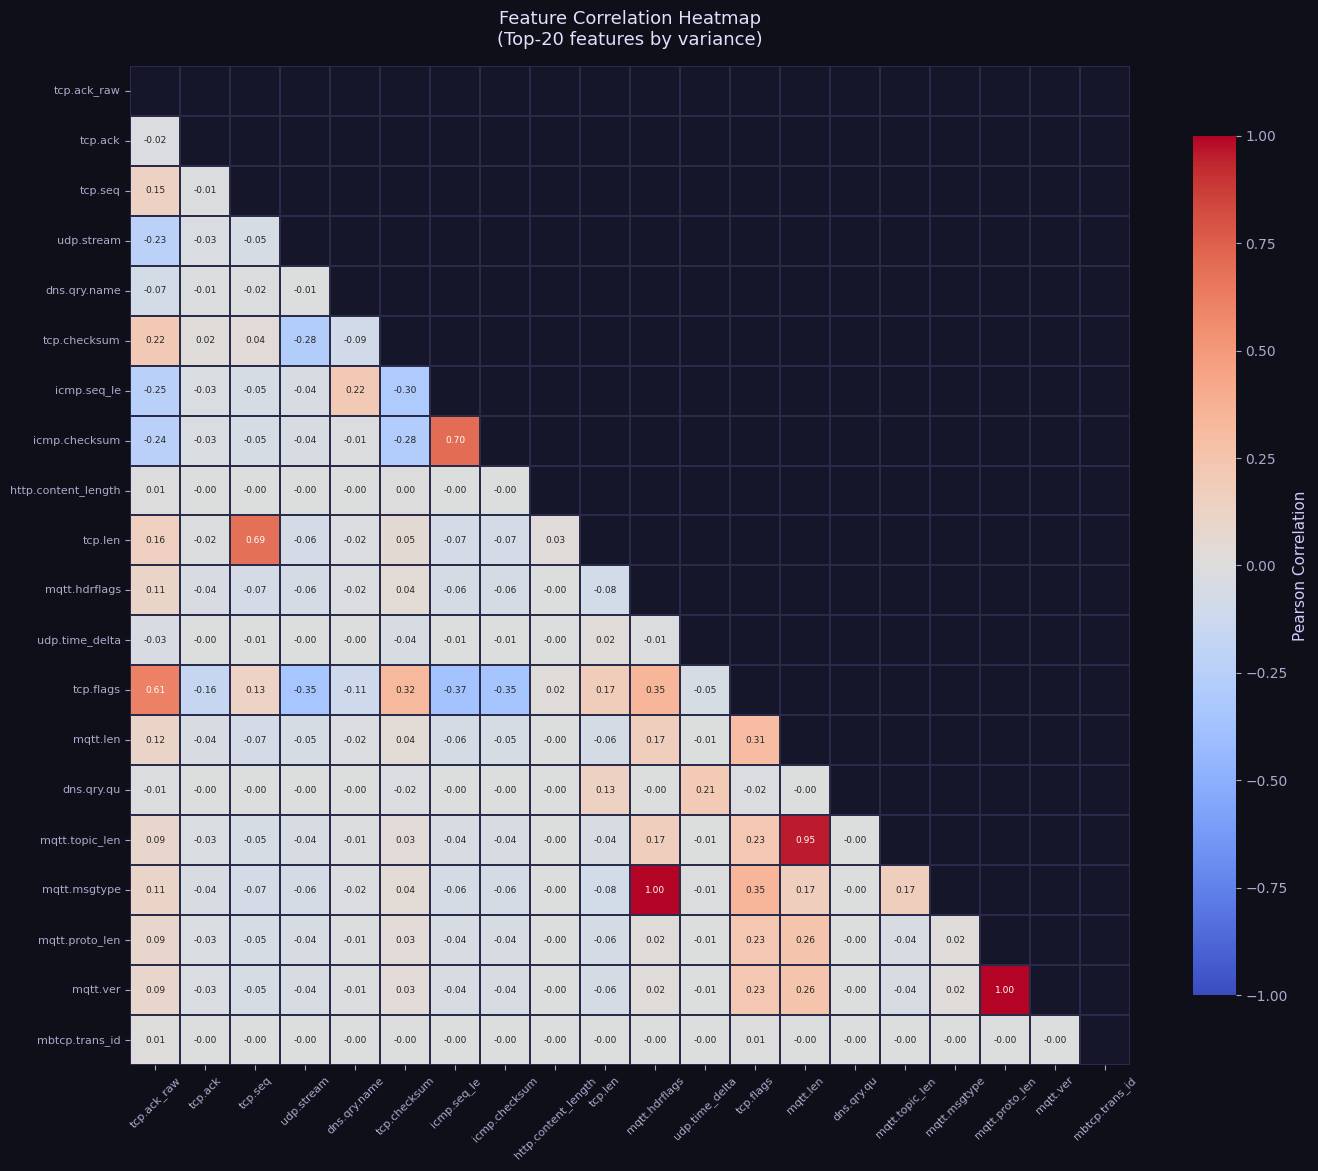

💾 Saved → ..\outputs\figures\N2/feature_correlation_heatmap.png


In [43]:
# ── Figure: Correlation heatmap (top 20 features by variance for readability) ──
top_var_cols = (
    df_sample[feature_cols]
    .astype(float)
    .var()
    .sort_values(ascending=False)
    .head(20)
    .index
    .tolist()
)

corr_top = df_sample[top_var_cols].astype(float).corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_top, dtype=bool))

sns.heatmap(
    corr_top,
    mask=mask,
    ax=ax,
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 6.5},
    linewidths=0.3,
    linecolor='#2a2a4a',
    square=True,
    cbar_kws={'shrink': 0.8, 'label': 'Pearson Correlation'},
)
ax.set_title(
    'Feature Correlation Heatmap\n(Top-20 features by variance)',
    fontsize=13, pad=15
)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0,  labelsize=8)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'feature_correlation_heatmap.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f'💾 Saved → {OUTPUT_DIR}/feature_correlation_heatmap.png')

## 🌲 Step 8 — Feature Importance (Random Forest)

Use a lightweight Random Forest to rank features by importance.
This mirrors **Algorithm 4 (Feature Selection)** from the Edge-IIoTset paper.

In [44]:
# ── Train a fast Random Forest on a sample ─────────────────────────
RF_SAMPLE  = 100000
TOP_N      = 30

print(f'🌲 Training Random Forest on {RF_SAMPLE:,} samples …')

# Simple sample to avoid pandas version issues with groupby().apply()
if len(df) > RF_SAMPLE:
    df_rf = df.sample(RF_SAMPLE, random_state=RANDOM_STATE).reset_index(drop=True)
else:
    df_rf = df.copy().reset_index(drop=True)

feature_cols = [c for c in df_rf.columns if c != TARGET_COLUMN]

X_df = df_rf[feature_cols].copy()
# Encode remaining categorical features if any
for col in X_df.select_dtypes(include=['object', 'category']).columns:
    X_df[col] = LabelEncoder().fit_transform(X_df[col].astype(str))

X_rf = X_df.astype(float).fillna(0).values
y_rf = LabelEncoder().fit_transform(df_rf[TARGET_COLUMN].astype(str))

rf = RandomForestClassifier(
    n_estimators = 100,
    max_depth    = 10,
    n_jobs       = -1,
    random_state = RANDOM_STATE,
    class_weight = 'balanced',
)
rf.fit(X_rf, y_rf)

# ── Feature importance ranking ─────────────────────────────────────────────────
importance_df = pd.DataFrame({
    'Feature'   : feature_cols,
    'Importance': rf.feature_importances_,
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print(f'\n📊 Top-{TOP_N} Most Important Features:\n')
print(f'  {"Rank":<6} {"Feature":<40} {"Importance":>12}')
print('  ' + '-' * 62)
for i, row in importance_df.head(TOP_N).iterrows():
    bar = '█' * int(row['Importance'] * 500)
    print(f'  [{i+1:>3}]  {row["Feature"]:<40} {row["Importance"]:>12.5f}  {bar}')

🌲 Training Random Forest on 100,000 samples …

📊 Top-30 Most Important Features:

  Rank   Feature                                    Importance
  --------------------------------------------------------------
  [  1]  tcp.len                                       0.10087  ██████████████████████████████████████████████████
  [  2]  tcp.ack                                       0.08800  ████████████████████████████████████████████
  [  3]  udp.stream                                    0.08418  ██████████████████████████████████████████
  [  4]  icmp.seq_le                                   0.08398  █████████████████████████████████████████
  [  5]  http.referer                                  0.08290  █████████████████████████████████████████
  [  6]  tcp.seq                                       0.06896  ██████████████████████████████████
  [  7]  http.request.version                          0.06107  ██████████████████████████████
  [  8]  http.request.method                         

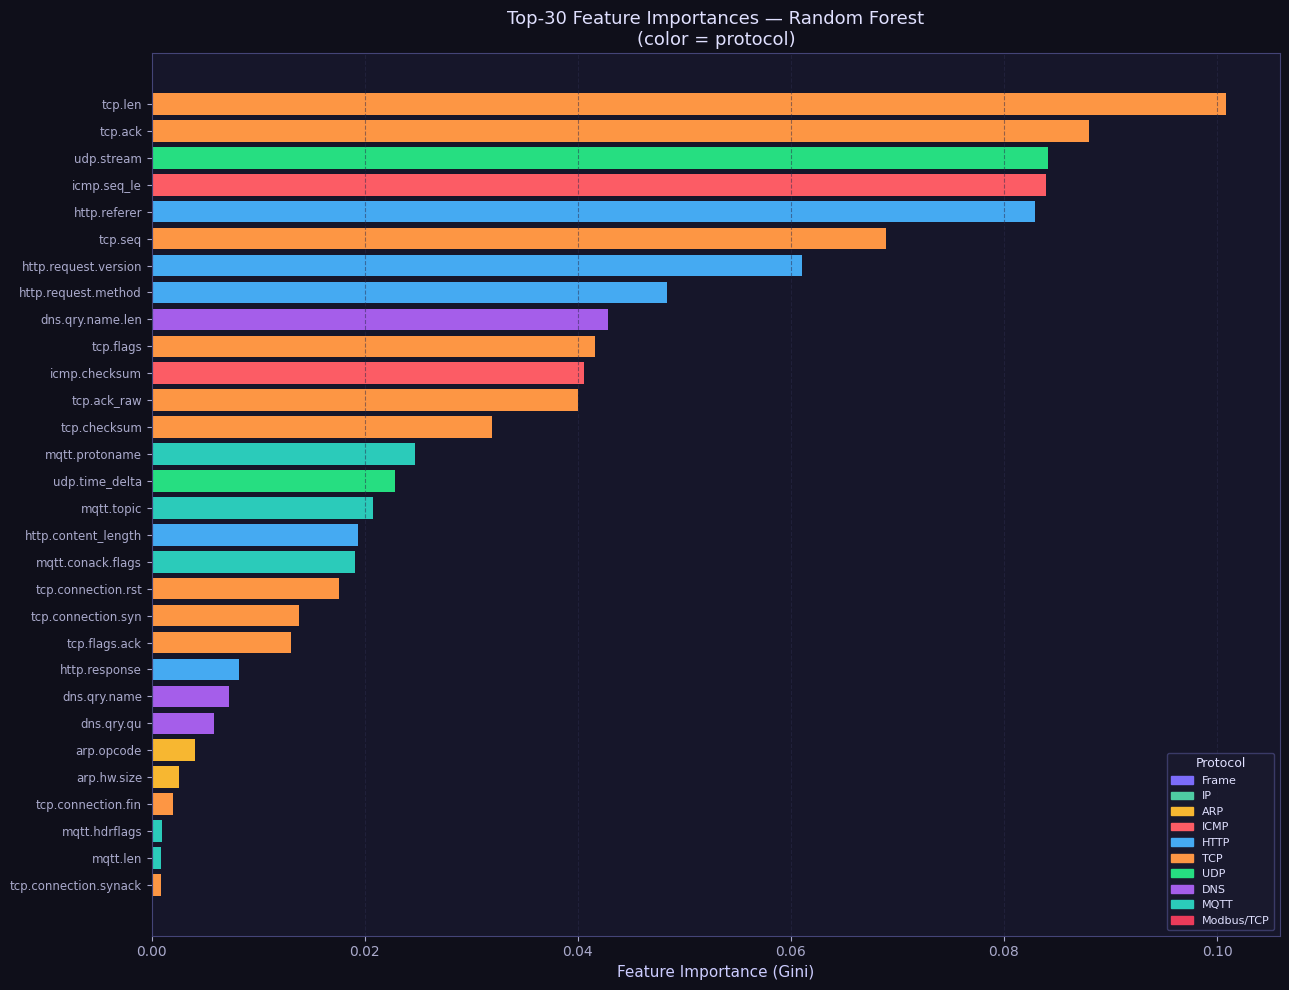

💾 Saved → ..\outputs\figures\N2/feature_importance.png


In [45]:
# ── Figure: Feature importance bar chart ──────────────────────────────────────
top_feats   = importance_df.head(TOP_N)
feat_colors = [
    PALETTE[list(FEATURES_BY_PROTOCOL.keys()).index(
        feature_to_protocol.get(f, 'Other')
    ) % len(PALETTE)]
    for f in top_feats['Feature']
]

fig, ax = plt.subplots(figsize=(13, 10))
bars = ax.barh(
    range(TOP_N), top_feats['Importance'].values,
    color=feat_colors, edgecolor='none'
)
ax.set_yticks(range(TOP_N))
ax.set_yticklabels(top_feats['Feature'].values, fontsize=8.5)
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title(
    f'Top-{TOP_N} Feature Importances — Random Forest\n'
    f'(color = protocol)',
    fontsize=13
)
ax.invert_yaxis()
ax.grid(axis='x')

# Protocol legend
proto_list = list(FEATURES_BY_PROTOCOL.keys())
legend_patches = [
    plt.Rectangle((0, 0), 1, 1,
                  color=PALETTE[i % len(PALETTE)],
                  label=proto)
    for i, proto in enumerate(proto_list)
]
ax.legend(
    handles=legend_patches,
    title='Protocol',
    loc='lower right',
    fontsize=8,
    title_fontsize=9,
)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'feature_importance.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f'💾 Saved → {OUTPUT_DIR}/feature_importance.png')

## ✔️ Step 9 — Final Feature Set Validation

In [46]:
# ── Final validation checks ───────────────────────────────────────────────────
feature_cols_final = [c for c in df.columns if c != TARGET_COLUMN]

print('🔍 Final Feature Set Validation\n')
print('=' * 60)

# Check 1: No nulls
null_counts = df[feature_cols_final].isnull().sum()
n_null_cols = (null_counts > 0).sum()
status = '✅' if n_null_cols == 0 else '⚠️ '
print(f'{status} Null columns       : {n_null_cols}')

# Check 2: No all-zero columns
zero_cols = [c for c in feature_cols_final
             if df[c].astype(float).sum() == 0]
status = '✅' if len(zero_cols) == 0 else '⚠️ '
print(f'{status} All-zero columns   : {len(zero_cols)}  {zero_cols if zero_cols else ""}')

# Check 3: No constant columns
const_cols = [c for c in feature_cols_final
              if df[c].nunique() <= 1]
status = '✅' if len(const_cols) == 0 else '⚠️ '
print(f'{status} Constant columns   : {len(const_cols)}  {const_cols if const_cols else ""}')

# Check 4: Feature count
status = '✅' if len(feature_cols_final) <= 61 else '⚠️ '
print(f'{status} Feature count      : {len(feature_cols_final)}  (paper target: ≤ 61)')

# Check 5: Target column present
status = '✅' if TARGET_COLUMN in df.columns else '❌'
print(f'{status} Target column      : "{TARGET_COLUMN}" present')

# Check 6: Class count
n_classes = df[TARGET_COLUMN].nunique()
status = '✅' if n_classes == 15 else '⚠️ '
print(f'{status} Class count        : {n_classes}  (expected: 15)')

print('=' * 60)
print(f'\n📊 Final dataset summary:')
print(f'   Rows        : {len(df):,}')
print(f'   Features    : {len(feature_cols_final)}')
print(f'   Target      : {TARGET_COLUMN}  ({n_classes} classes)')
print(f'   RAM usage   : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')

print(f'\n📋 Final feature list:')
for i, col in enumerate(feature_cols_final, 1):
    proto = feature_to_protocol.get(col, 'Other')
    print(f'   [{i:>3}] {col:<45} [{proto}]')

🔍 Final Feature Set Validation

✅ Null columns       : 0
⚠️  All-zero columns   : 4  ['icmp.unused', 'http.tls_port', 'dns.qry.type', 'mqtt.msg_decoded_as']
⚠️  Constant columns   : 4  ['icmp.unused', 'http.tls_port', 'dns.qry.type', 'mqtt.msg_decoded_as']
✅ Feature count      : 46  (paper target: ≤ 61)
✅ Target column      : "Attack_type" present
✅ Class count        : 15  (expected: 15)

📊 Final dataset summary:
   Rows        : 2,218,386
   Features    : 46
   Target      : Attack_type  (15 classes)
   RAM usage   : 940.8 MB

📋 Final feature list:
   [  1] arp.opcode                                    [ARP]
   [  2] arp.hw.size                                   [ARP]
   [  3] icmp.checksum                                 [ICMP]
   [  4] icmp.seq_le                                   [ICMP]
   [  5] icmp.unused                                   [ICMP]
   [  6] http.content_length                           [HTTP]
   [  7] http.request.method                           [HTTP]
   [  8] ht

## 💾 Step 10 — Save Extracted Features

In [47]:
PROC_DIR.mkdir(parents=True, exist_ok=True)
df.to_csv(OUTPUT_PATH, index=False)

saved_size = OUTPUT_PATH.stat().st_size / 1e6
print(f'✅ Feature-extracted dataset saved.')
print(f'   Path     : {OUTPUT_PATH.resolve()}')
print(f'   Rows     : {len(df):,}')
print(f'   Columns  : {df.shape[1]}  ({df.shape[1]-1} features + 1 target)')
print(f'   Size     : {saved_size:.1f} MB')

✅ Feature-extracted dataset saved.
   Path     : C:\Users\kaush\Desktop\LLM Threat Detection on IIOT\SecurityBERT CLAUDE\data\processed\features_extracted.csv
   Rows     : 2,218,386
   Columns  : 47  (46 features + 1 target)
   Size     : 430.0 MB


---
## ✅ Summary — Notebook 02 Outputs

| Artefact | Location |
|----------|----------|
| `features_extracted.csv` | `data/processed/features_extracted.csv` |
| Protocol breakdown chart | `outputs/figures/feature_protocol_breakdown.png` |
| Correlation heatmap | `outputs/figures/feature_correlation_heatmap.png` |
| Feature importance chart | `outputs/figures/feature_importance.png` |

---

### Key Decisions Made

| Decision | Rationale |
|----------|-----------|
| Drop IP columns | Cause overfitting — unique per network |
| Drop timestamps | Millisecond precision = noise, not signal |
| Drop raw payloads | Unstructured content — requires separate NLP pipeline |
| Drop high-cardinality URIs | Non-generalizable across deployments |
| Label encode remaining strings | Required for numeric ML processing |
| Random Forest importance | Validates feature relevance before PPFLE |

---

### 🔜 Carry Forward to Notebook 03 — PPFLE Encoding

```python
INPUT_PATH    = 'data/processed/features_extracted.csv'
TARGET_COLUMN = 'Attack_type'
N_FEATURES    = 46   # final count after dropping non-informative columns
# Each feature will become: H(column_name$value) = 32-char MD5 token
# Sequence per row = space-joined list of all feature tokens
```